In [ ]:
pip install opencv-contrib-python

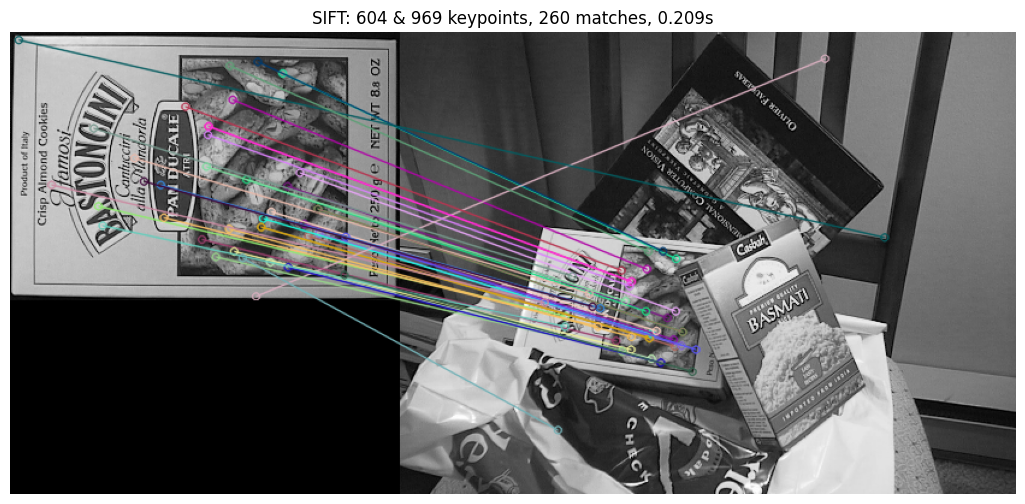

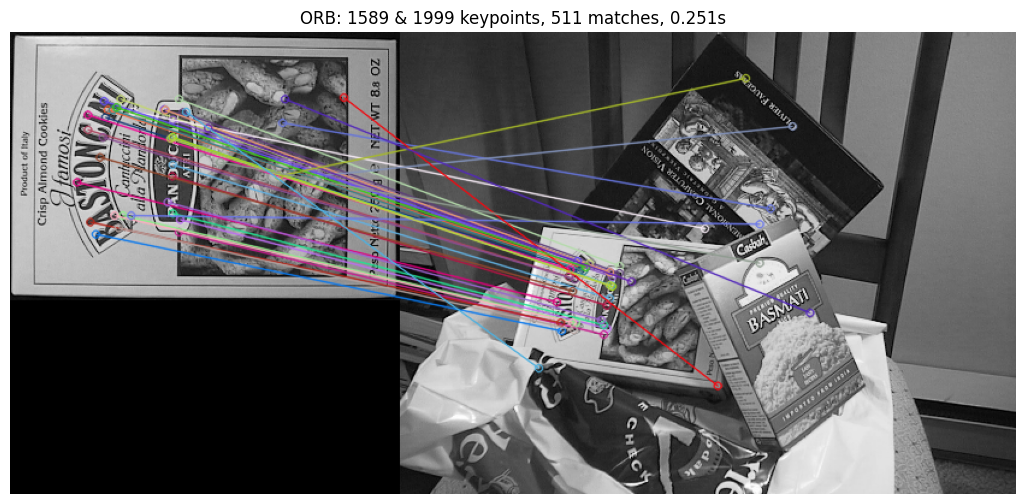

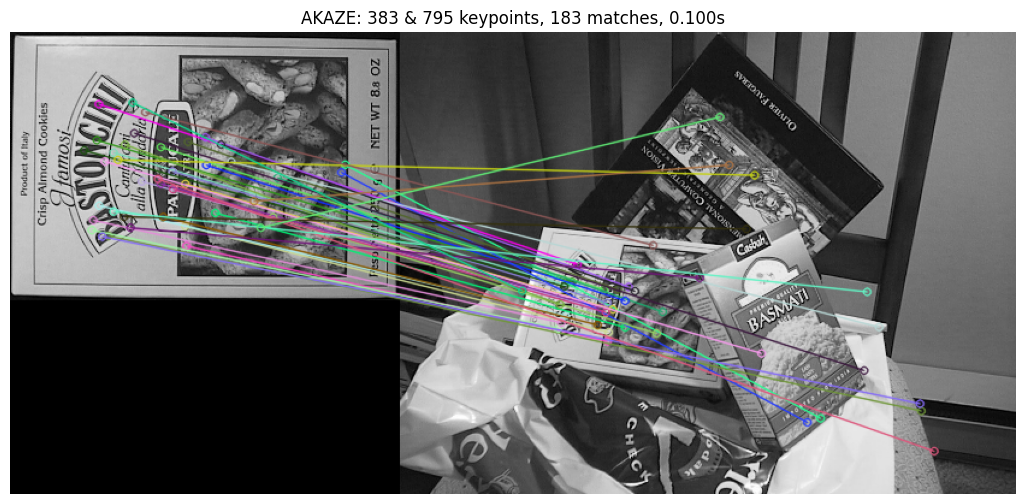

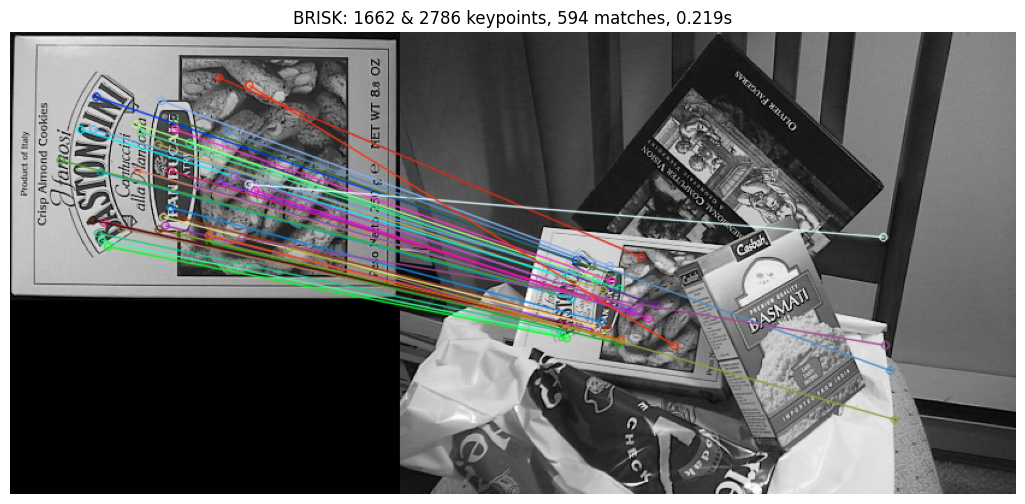

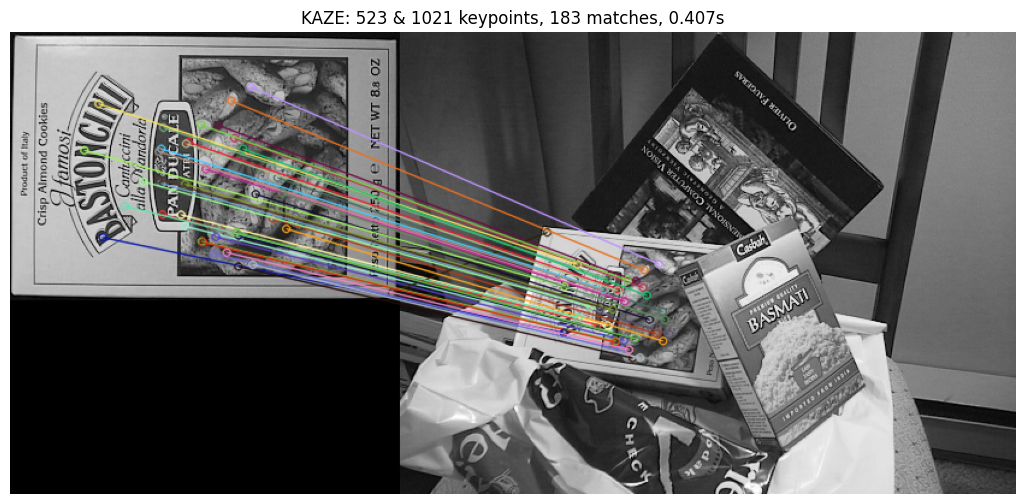


AlgorithmKP img1   KP img2   Matches   Time(s)   
SIFT    604       969       260       0.209     
ORB     1589      1999      511       0.251     
AKAZE   383       795       183       0.1       
BRISK   1662      2786      594       0.219     
KAZE    523       1021      183       0.407     


'\nWHAT TO LOOK FOR when you compare:\n- More keypoints isn\'t automatically "better" — what matters is how many\n  survive as GOOD matches (i.e. correctly found the same real-world point\n  in both images).\n- Time matters a lot for near-real-time landing/navigation use cases.\n- Visually check the match lines: do they connect the SAME physical\n  points across both images, or are there criss-crossed wrong matches?\n'

In [ ]:
"""
6.5 Feature Detection — test SIFT / ORB / AKAZE / BRISK / KAZE on an image pair.

HOW TO USE (Colab):
1. Upload box.png and box_in_scene.png (or your own 2 photos of the same
   object/scene taken from different angles/lighting) using the Colab
   file upload panel, or mount Drive.
2. Run this cell. It loops through every classical detector, finds
   keypoints in both images, matches them, and prints + plots the results.
3. Look at the printed table at the end to compare them.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# ---- 1. Load images (grayscale) ----
img1 = cv2.imread("box.png", cv2.IMREAD_GRAYSCALE)          # the "object"
img2 = cv2.imread("box_in_scene.png", cv2.IMREAD_GRAYSCALE)  # same object, different angle/lighting/scale

assert img1 is not None and img2 is not None, "Check your file paths / uploaded filenames"

# ---- 2. Define every classical detector ----
# Binary-descriptor detectors (ORB, AKAZE, BRISK) -> use Hamming distance matcher
# Float-descriptor detectors (SIFT, KAZE) -> use L2 distance matcher
detectors = {
    "SIFT":  (cv2.SIFT_create(),               cv2.NORM_L2),
    "ORB":   (cv2.ORB_create(nfeatures=2000),   cv2.NORM_HAMMING),
    "AKAZE": (cv2.AKAZE_create(),               cv2.NORM_HAMMING),
    "BRISK": (cv2.BRISK_create(),               cv2.NORM_HAMMING),
    "KAZE":  (cv2.KAZE_create(),                cv2.NORM_L2),
}

results = []

for name, (detector, norm) in detectors.items():
    t0 = time.time()

    # detect + describe
    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)

    # match descriptors
    bf = cv2.BFMatcher(norm, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda m: m.distance)

    elapsed = time.time() - t0

    results.append({
        "name": name,
        "kp1": len(kp1),
        "kp2": len(kp2),
        "good_matches": len(matches),
        "time_sec": round(elapsed, 3),
    })

    # visualize top 40 matches
    match_img = cv2.drawMatches(
        img1, kp1, img2, kp2, matches[:40], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    plt.figure(figsize=(14, 6))
    plt.imshow(match_img, cmap="gray")
    plt.title(f"{name}: {len(kp1)} & {len(kp2)} keypoints, {len(matches)} matches, {elapsed:.3f}s")
    plt.axis("off")
    plt.savefig(f"matches_{name}.png", bbox_inches="tight", dpi=120)
    plt.show()

# ---- 3. Print comparison table ----
print(f"\n{'Algorithm':<8}{'KP img1':<10}{'KP img2':<10}{'Matches':<10}{'Time(s)':<10}")
for r in results:
    print(f"{r['name']:<8}{r['kp1']:<10}{r['kp2']:<10}{r['good_matches']:<10}{r['time_sec']:<10}")

"""
WHAT TO LOOK FOR when you compare:
- More keypoints isn't automatically "better" — what matters is how many
  survive as GOOD matches (i.e. correctly found the same real-world point
  in both images).
- Time matters a lot for near-real-time landing/navigation use cases.
- Visually check the match lines: do they connect the SAME physical
  points across both images, or are there criss-crossed wrong matches?
"""

In [ ]:
!wget -q https://raw.githubusercontent.com/opencv/opencv/4.x/samples/python/asift.py
!wget -q https://raw.githubusercontent.com/opencv/opencv/4.x/samples/python/common.py
!wget -q https://raw.githubusercontent.com/opencv/opencv/4.x/samples/python/find_obj.py

import cv2
import numpy as np

from asift import affine_detect, init_feature

print("ASIFT imported successfully!")

ASIFT imported successfully!


In [ ]:
from multiprocessing.pool import ThreadPool
pool = ThreadPool(processes=cv2.getNumberOfCPUs())

In [ ]:
detector, matcher = init_feature('sift-flann')
kp1, desc1 = affine_detect(detector, img1, pool=pool)
kp2, desc2 = affine_detect(detector, img2, pool=pool)

affine sampling: 43 / 43
affine sampling: 43 / 43


ASIFT good matches: 3700


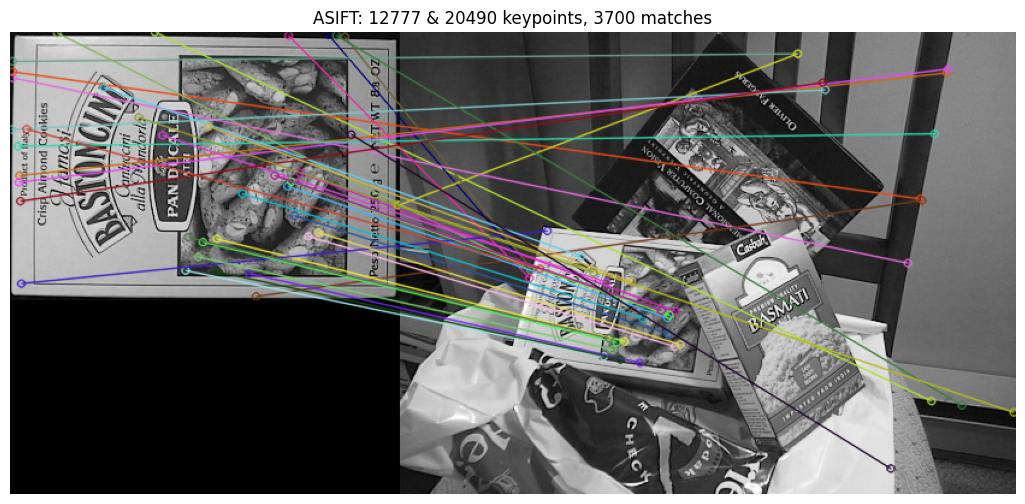

In [ ]:
# ASIFT uses SIFT descriptors under the hood, so match like SIFT (L2 norm)
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(desc1, desc2)
matches = sorted(matches, key=lambda m: m.distance)

print("ASIFT good matches:", len(matches))

match_img = cv2.drawMatches(
    img1, kp1, img2, kp2, matches[:40], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.figure(figsize=(14, 6))
plt.imshow(match_img, cmap="gray")
plt.title(f"ASIFT: {len(kp1)} & {len(kp2)} keypoints, {len(matches)} matches")
plt.axis("off")
plt.show()